In [23]:
# importuri

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import time # Adaugă asta la lista ta de importuri, sus de tot

In [24]:
# Verifică dacă CUDA (suportul pentru plăci video NVIDIA) este disponibil
gpu_disponibil = torch.cuda.is_available()
print(f"GPU disponibil pentru antrenare: {gpu_disponibil}")

if gpu_disponibil:
    # Afișează numărul de plăci video și numele acestora
    nr_gpu = torch.cuda.device_count()
    print(f"Număr GPU-uri detectate: {nr_gpu}")
    for i in range(nr_gpu):
        print(f"Nume GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("Atenție: PyTorch folosește procesorul (CPU). Antrenarea va fi lentă!")

GPU disponibil pentru antrenare: True
Număr GPU-uri detectate: 1
Nume GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU


In [25]:
# ==========================================
# 1. Definirea Setului de Date (Custom Dataset)
# ==========================================
class APTOSDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.dataframe = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Numele imaginii - adăugăm .png dacă nu există în CSV
        img_name = str(self.dataframe.iloc[idx, 0])
        if not img_name.endswith('.png'):
            img_name += '.png'
            
        img_path = os.path.join(self.img_dir, img_name)
        
        # Încărcăm imaginea
        image = Image.open(img_path).convert('RGB')
        
        # Eticheta binară: 0 (Normal) vs 1 (Retinopatie - clasele 1,2,3,4)
        label_initial = int(self.dataframe.iloc[idx, 1])
        label_binar = 0 if label_initial == 0 else 1
        label = torch.tensor(label_binar, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [26]:
# ==========================================
# 2. Preprocesare și Augmentare (Conform SOTA)
# ==========================================
# Redimensionăm la 224x224 (standard pentru ResNet) și normalizăm cu valorile ImageNet
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Augmentare simplă
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [27]:
# ==========================================
# 3. Pregătirea Datelor (DataLoaders)
# ==========================================
# Căile exacte conform structurii tale
train_csv = "../Dataset_APTOS_2019/train_1.csv"
train_dir = "../Dataset_APTOS_2019/train_images/train_images"

test_csv = "../Dataset_APTOS_2019/test.csv"
test_dir = "../Dataset_APTOS_2019/test_images/test_images"

# Instanțiem dataset-urile
train_dataset = APTOSDataset(csv_path=train_csv, img_dir=train_dir, transform=train_transforms)
test_dataset = APTOSDataset(csv_path=test_csv, img_dir=test_dir, transform=test_transforms)

# Instanțiem DataLoaders (batch_size=32 e un standard bun pentru GPU-uri de 8GB+)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Imagini antrenare: {len(train_dataset)} | Imagini testare: {len(test_dataset)}")

Imagini antrenare: 2930 | Imagini testare: 366


In [28]:
# ==========================================
# 4. Definirea Modelului (Transfer Learning)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rulăm pe: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 1)
)
model = model.to(device)


Rulăm pe: cuda


In [29]:
# ==========================================
# 5. Funcția de Loss și Optimizatorul
# ==========================================
# Pentru clasificare binară cu un singur output liniar, folosim BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()

# Antrenăm doar ultimul strat (model.fc) pe care l-am adăugat noi
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [30]:
# ==========================================
# 6. Bucla de Antrenare cu Validare și Salvare Model
# ==========================================
num_epochs = 50

# Aici vom stoca istoricul pentru grafic
istoric_train_loss = []
istoric_test_loss = []

# --- NOU: Variabilă pentru a urmări cel mai bun loss de validare ---
best_val_loss = float('inf') # Inițializăm cu infinit, ca orice loss să fie mai mic

print("Începe antrenamentul...")
for epoch in range(num_epochs):
    
    # NEMODIFICAT: Pornim cronometrul
    start_time = time.time()
    
    # --- ETAPA DE ANTRENAMENT (NEMODIFICAT) ---
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    istoric_train_loss.append(avg_train_loss)
    
    # --- ETAPA DE TESTARE / VALIDARE (NEMODIFICAT) ---
    model.eval()
    running_test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_test_loss += loss.item()
            
    avg_test_loss = running_test_loss / len(test_loader)
    istoric_test_loss.append(avg_test_loss)
    
    # NEMODIFICAT: Oprim cronometrul și calculăm timpul
    end_time = time.time()
    timp_total_secunde = end_time - start_time
    minute = int(timp_total_secunde // 60)
    secunde = int(timp_total_secunde % 60)
    
    # --- NOU: Modificăm puțin print-ul pentru a nu trece pe linia următoare imediat ---
    print(f"Epoca [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Timp: {minute}m {secunde}s", end="")
    
    # ==========================================
    # --- NOU: LOGICA DE SALVARE A MODELULUI ---
    # ==========================================
    if avg_test_loss < best_val_loss:
        # Dacă loss-ul curent e mai mic decât cel mai bun de până acum, actualizăm
        best_val_loss = avg_test_loss
        
        # Salvăm DOAR greutățile modelului (state_dict), e cea mai eficientă metodă
        torch.save(model.state_dict(), 'best_model_resnet50.pth')
        
        # Afișăm un mesaj ca să știm că în această epocă modelul s-a îmbunătățit
        print(f"  --> Model salvat! (Loss nou record: {best_val_loss:.4f})")
    else:
        # Dacă nu s-a îmbunătățit, doar trecem la linia următoare în consolă
        print()

print("\nAntrenamentul s-a terminat!")

# --- NOU: Opțional, putem salva și modelul de la ultima epocă (Epoca 50) ---
torch.save(model.state_dict(), 'last_model_resnet50_ep50.pth')
print("Modelul final (epoca 50) a fost salvat ca 'last_model_resnet50_ep50.pth'")

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.3733 | Test Loss: 0.2229 | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.2229)
Epoca [2/50] | Train Loss: 0.2253 | Test Loss: 0.1757 | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.1757)
Epoca [3/50] | Train Loss: 0.1970 | Test Loss: 0.1579 | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.1579)
Epoca [4/50] | Train Loss: 0.1926 | Test Loss: 0.1699 | Timp: 1m 8s
Epoca [5/50] | Train Loss: 0.1857 | Test Loss: 0.1480 | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.1480)
Epoca [6/50] | Train Loss: 0.1981 | Test Loss: 0.2126 | Timp: 1m 7s
Epoca [7/50] | Train Loss: 0.1722 | Test Loss: 0.1303 | Timp: 1m 8s  --> Model salvat! (Loss nou record: 0.1303)
Epoca [8/50] | Train Loss: 0.1648 | Test Loss: 0.1302 | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.1302)
Epoca [9/50] | Train Loss: 0.1660 | Test Loss: 0.1482 | Timp: 1m 7s
Epoca [10/50] | Train Loss: 0.1674 | Test Loss: 0.1780 | Timp: 1m 7s
Epoca [11/50] | Train Los


Antrenamentul s-a terminat! Graficul a fost salvat ca 'grafic_loss_resnet50.png'.


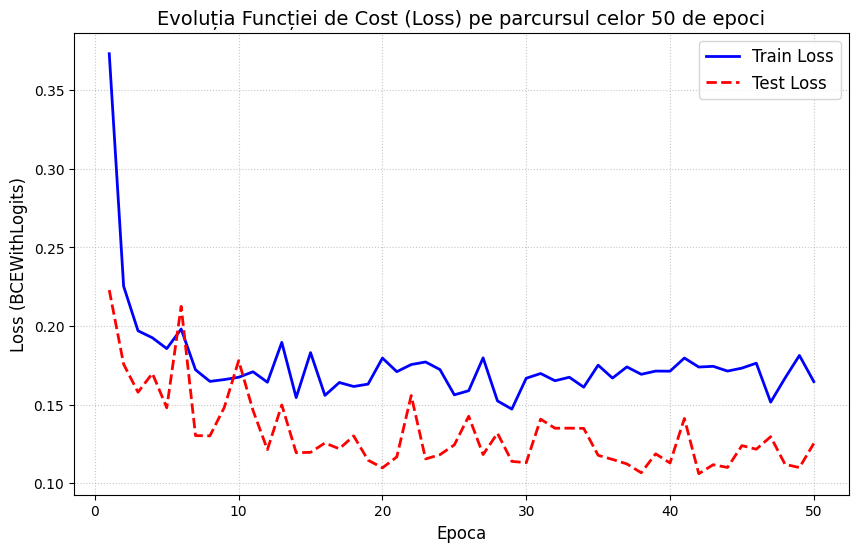

In [33]:
# ==========================================
# 7. Generarea și Salvarea Graficului
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), istoric_train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, num_epochs + 1), istoric_test_loss, label='Test Loss', color='red', linestyle='--', linewidth=2)

plt.title('Evoluția Funcției de Cost (Loss) pe parcursul celor 50 de epoci', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Loss (BCEWithLogits)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Salvăm graficul ca imagine ca să îl poți pune direct în disertație
plt.savefig('grafic_loss_resnet50.png', dpi=300, bbox_inches='tight')
print("\nAntrenamentul s-a terminat! Graficul a fost salvat ca 'grafic_loss_resnet50.png'.")
plt.show()

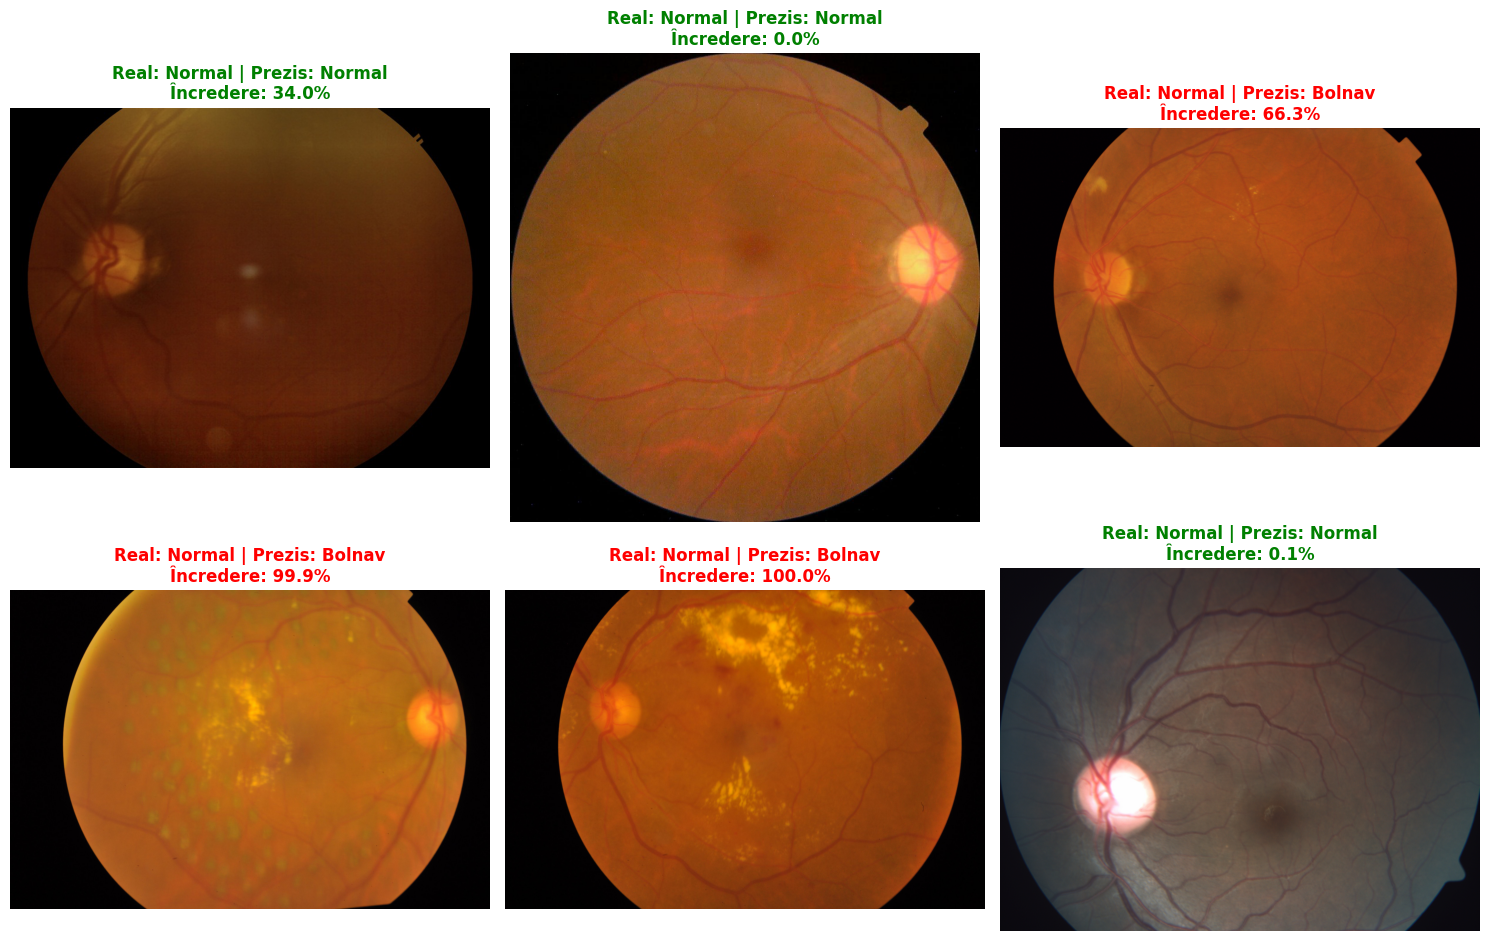

In [34]:
def vizualizare_predictii(model, device, test_csv_path, test_images_dir, num_imagini=6):
    """
    Alege aleatoriu un număr de imagini, face predicția și le afișează într-o grilă.
    """
    # 1. Încărcăm etichetele reale (Ground Truth)
    test_df = pd.read_csv(test_csv_path)
    
    # Alegem câteva rânduri la întâmplare
    sample_df = test_df.sample(n=num_imagini)
    
    # 2. Definim transformările pentru inferență
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    model.eval()
    
    # 3. Pregătim figura pentru afișare (ex: 2 rânduri, 3 coloane pentru 6 imagini)
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for i, (index, row) in enumerate(sample_df.iterrows()):
            img_name = str(row.iloc[0])
            if not img_name.endswith('.png'):
                img_name += '.png'
                
            img_path = os.path.join(test_images_dir, img_name)
            adevarul_absolut = int(row.iloc[1]) # Ce a zis medicul (clasa reală)
            
            # Încărcăm imaginea originală pentru afișare vizuală
            try:
                image_pil = Image.open(img_path).convert('RGB')
            except FileNotFoundError:
                print(f"Imaginea {img_name} nu a fost găsită.")
                continue

            # Preprocesăm pentru model
            image_tensor = val_transforms(image_pil).unsqueeze(0).to(device)

            # Facem predicția
            raw_output = model(image_tensor)
            probability = torch.sigmoid(raw_output).item()
            predictie_model = 1 if probability >= 0.5 else 0
            
            # 4. Afișarea în grilă
            ax = fig.add_subplot(2, 3, i+1) # Ajustează dacă schimbi numărul de imagini
            ax.imshow(image_pil)
            ax.axis('off') # Ascundem axele (X, Y) ca să arate curat
            
            # Construim textul
            diagnostic_real = "Bolnav" if adevarul_absolut == 1 else "Normal"
            diagnostic_prezis = "Bolnav" if predictie_model == 1 else "Normal"
            
            titlu = f"Real: {diagnostic_real} | Prezis: {diagnostic_prezis}\nÎncredere: {probability*100:.1f}%"
            
            # Colorăm verde dacă e corect, roșu dacă a greșit
            culoare = "green" if adevarul_absolut == predictie_model else "red"
            ax.set_title(titlu, color=culoare, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================
# Apelarea funcției:
# ==========================================
vizualizare_predictii(model, device, "../Dataset_APTOS_2019/test.csv", "../Dataset_APTOS_2019/test_images/test_images", num_imagini=6)